# MALDI Data Processed to Training Data

<b>Author:</b> Annalena Weissert\
<b>Last Edited:</b> 16 July 2026 

<b>Input:</b> Processed Data. By default this script uses the data "ExampleData_Processed", created via "0_Data_raw_to_processed.ipynb". To recreate the results from the paper use the dataset provided under https://doi.org/10.17877/RTG2624-2026-MRKM1K1K \
<b>Output:</b> A folder including all Training data. While the Processed Data contains one .pt file for each specimen (incl. all corresponding images), the training data saves each training image as a .pt file to easily access random batches during training.

<b>Note: </b> Commands where (relative) paths or values may need to be adjusted are marked with '#!'. By default this file runs on the "ExampleData_Processed" folder, if the same folder structure as in github is provided.

In [1]:
## Packages
import os        
import numpy as np
import torch

import skimage.measure              # for entropy
import matplotlib.pyplot as plt     # visualization

## Example Data
processed_data_path = "ExampleData_Processed"  #! Relative path to the folder containing the processed .pt data files
training_data_path = "ExampleData_Training"    #! Relative path to the folder where the training data will be saved
exclude_tumors = ["ExampleTumor5.pt","ExampleTumor6.pt"]        #! Define names of validation and test tumors as they should not be included in the training data

## Real Data (naming convention equivalent to the provided dataset)
#processed_data_path = "Processed_Data"  
#training_data_path = "Training_Data"    
#exclude_tumors = ['Edi3-Metastase-M1-Lu-Left.pt','Edi3-Metastase-M19-Lu-Left.pt','Edi3-Metastase-M10-Lu-right.pt',
#                 'Primaer-Tumor-M18.pt','Primaer-Tumor-M4.pt','Primaer-Tumor-M3.pt',
#                 'Rezidiv-Tumor-M22.pt','Rezidiv-Tumor-M21.pt', 'Rezidiv-Tumor-M3.pt' ]    

## Detect low entropy images and exclude them from the training data

The intensity maps of some m/z-values contain little to no information and are not suitable as training images.\
Since the algorithm is supposed to learn shape comparisons, training images that are almost empty or purely noise may be counterproductive to the training process.\
We filter them using shannon entropy.

In [2]:
# Set working directory to the folder with processed data
os.chdir(processed_data_path)

# List all files (should only contain tumors and a tensor with mz values, named "00mz_names.pt")
all_training_files = np.array(sorted(os.listdir()))
all_training_files = all_training_files[~np.isin(all_training_files, exclude_tumors)]         # Exclude validation tumors from training data
all_training_files = np.delete(all_training_files, np.where(all_training_files=="00mz_names.pt")[0][0]) # exclude mz name vector from list file

In [3]:
## Load all tumors in one tensor (this may not be possible if the dataset is too large)

# Load the first tumor to extract image size and number of m/z-values (assuming all tumors share these variables and the images are squared)
first_tumor = torch.load(all_training_files[0])
number_mz, _, size, _ = first_tumor.shape
del first_tumor # clear memory

number_tumors = len(all_training_files)
tumors = torch.zeros((number_tumors, number_mz, 1, size, size)) # Define empty tensor 
for _ in range(number_tumors): 
    tumors[_] = torch.load(all_training_files[_]) # load and save all specimen

# Calculate the shannon entropy for each m/z intensity map of each mouse
entropy = np.zeros((number_tumors, number_mz))
for mouse in range(number_tumors):
    for mz1 in range(number_mz):
        entropy[mouse, mz1] = skimage.measure.shannon_entropy(tumors[mouse, mz1,:,:,:]) 

# Normalize Entropy to 99.8% quantile (exclude outliers)
entropy_norm = entropy.copy() 
for m in range(number_tumors):
    q998 = np.quantile(entropy_norm[m],0.998)  
    entropy_norm[m][entropy_norm[m] > q998] = q998 # cap to quantile 
    entropy_norm[m] = entropy_norm[m] / np.max(entropy_norm[m])  # divide by max per mouse

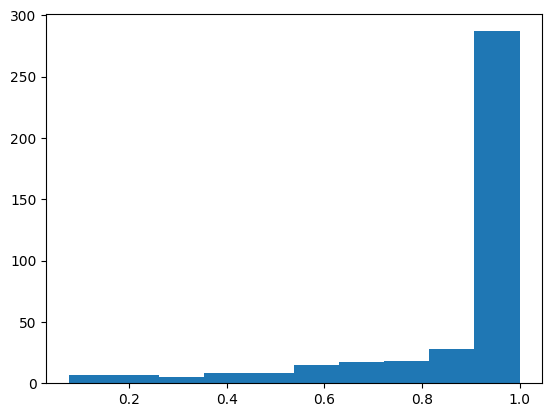

In [4]:
# Histogam Entropy over all tumors
entropy_norm_array = np.squeeze(entropy_norm.reshape((1,-1)))
_ = plt.hist(entropy_norm_array)

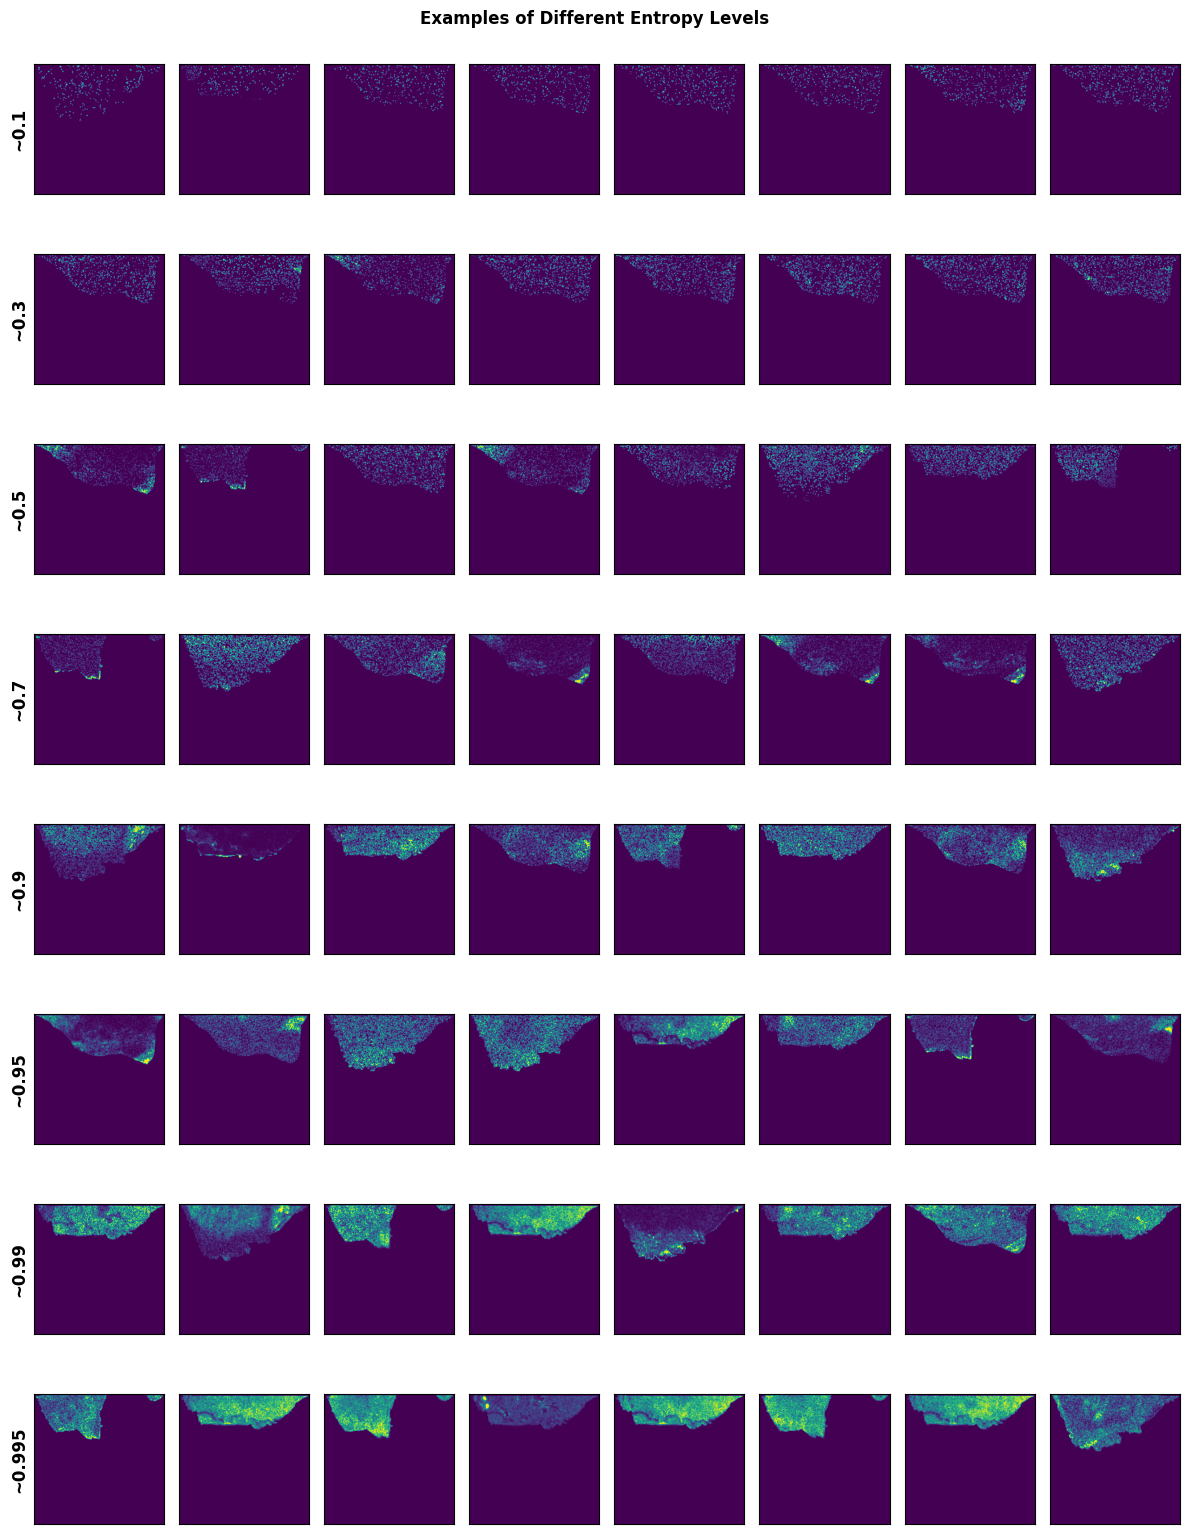

In [5]:
# Display a few examples for different levels of entropy
entropy_sort = np.sort(entropy_norm_array)
display_entropy = [0.1,0.3,0.5,0.7,0.9,0.95,0.99,0.995]
idx_matrix = np.zeros((len(display_entropy),8,2))
for id, cutoff in enumerate(display_entropy):
    value = entropy_sort[np.where(entropy_sort > cutoff)[0][0:8]] # take the first 8 values higher or equal to the cutoff value
    idx_matrix[id] = [[np.where(entropy_norm == i)[0][0], np.where(entropy_norm == i)[1][0]] for i in value]

img_list = np.squeeze(np.array(tumors[idx_matrix[:,:,0].reshape(1,-1), idx_matrix[:,:,1].reshape(1,-1), 0]))
fig, axes = plt.subplots(len(display_entropy), 8, figsize=(12, len(display_entropy)*2))
fig.suptitle("Examples of Different Entropy Levels",  fontweight='bold')
for img, ax in zip(img_list, axes.ravel()):
            ax.set_xticks([])
            ax.set_yticks([])
            ax.imshow(img)
            if ax.get_subplotspec().is_first_col():
                row = ax.get_subplotspec().rowspan.start
                ax.set_ylabel(f"~{display_entropy[row]}",  fontweight='bold', fontsize=12)
fig.tight_layout() 

In [6]:
for i in display_entropy:
    print("entropy larger or equal than",i,"for",round(np.sum(entropy_norm >= i) * 100 / (number_tumors * number_mz),1),"%")

entropy larger or equal than 0.1 for 99.5 %
entropy larger or equal than 0.3 for 96.2 %
entropy larger or equal than 0.5 for 92.5 %
entropy larger or equal than 0.7 for 84.2 %
entropy larger or equal than 0.9 for 72.0 %
entropy larger or equal than 0.95 for 67.0 %
entropy larger or equal than 0.99 for 56.5 %
entropy larger or equal than 0.995 for 46.5 %


Based on these observations (for the real data) we decided to use 0.9 as the cutoff, suggesting that images with normalized entropy below 0.9 mostly contain too little information for useful training.\
For the real data this excluded 13.7 % of images from the training set. The remaining dataset was still large enough for efficient training (28,777 out of 33,364).

In [7]:
## Save the dataset. Each image is saved in the format img_[0-9]*_[TumorFilename.pt]
entropy_threshold = 0.9         #! Set entropy threshold 

os.chdir("".join(["../",training_data_path]))
tumor_entropy09 = tumors[entropy_norm > 0.9]
tumor_names = np.repeat(all_training_files, number_mz).reshape(number_tumors,number_mz)
tumor_names09 = tumor_names[entropy_norm > 0.9]
amount = tumor_entropy09.shape[0]
for img in range(amount):
    save_tumor = tumor_entropy09[img].clone() 
    torch.save(save_tumor,"".join(["img_",str(img),"_",tumor_names09[img]]))
    if(img%100 == 0):
        print("Progress:",img,"-",round(img*100/amount,2),"%")

Progress: 0 - 0.0 %
Progress: 100 - 34.72 %
Progress: 200 - 69.44 %
